In [2]:
import os
for f in os.listdir(r"C:\Users\Welcome Sir\Downloads"):
    if f.endswith(".csv"):
        print(f)

77266340-2b93-406c-aac8-a8c635d7aed1 (1).csv
77266340-2b93-406c-aac8-a8c635d7aed1.csv
85334965-5736-457a-b8d4-a077e6872f84 (1).csv
85334965-5736-457a-b8d4-a077e6872f84 (2).csv
85334965-5736-457a-b8d4-a077e6872f84.csv
b9526704-40ff-442f-88e4-df8efc491321.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = pd.read_csv(r"C:\Users\Welcome Sir\Downloads\85334965-5736-457a-b8d4-a077e6872f84.csv")
print(df.shape)
print(df.head())
print(df.describe())
print(df.isnull().sum())

(4572, 4)
     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181
                TV        Radio  Social_Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.212670    93.133092
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.525957      1.527849   112.322882
50%      53.000000    17.859513      3.055565   189.231172
75%      77.000000    25.649730      4.807558   272.507922
max     100.000000    48.871161     13.981662   364.079751
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


In [4]:
# Drop missing values
df = df.dropna()
print("Shape after cleaning:", df.shape)
print(df.isnull().sum())

Shape after cleaning: (4546, 4)
TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64


TV              0.999497
Radio           0.868638
Social_Media    0.527446
Sales           1.000000
Name: Sales, dtype: float64


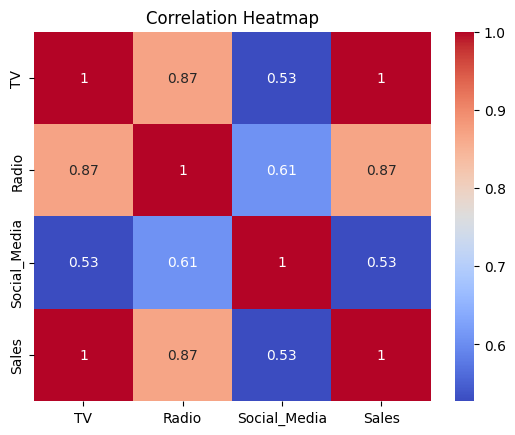

In [5]:
# Check correlation with Sales
correlation = df.corr()
print(correlation['Sales'])

# Visualize correlation
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

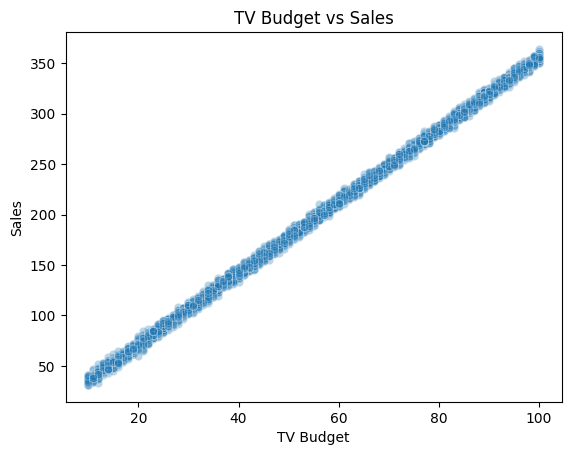

In [6]:
# Scatterplot of TV vs Sales
sns.scatterplot(x='TV', y='Sales', data=df, alpha=0.3)
plt.title('TV Budget vs Sales')
plt.xlabel('TV Budget')
plt.ylabel('Sales')
plt.show()

In [7]:
# Build OLS regression model
model = smf.ols(formula='Sales ~ TV', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        08:51:15   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1325      0.101     -1.317      0.1

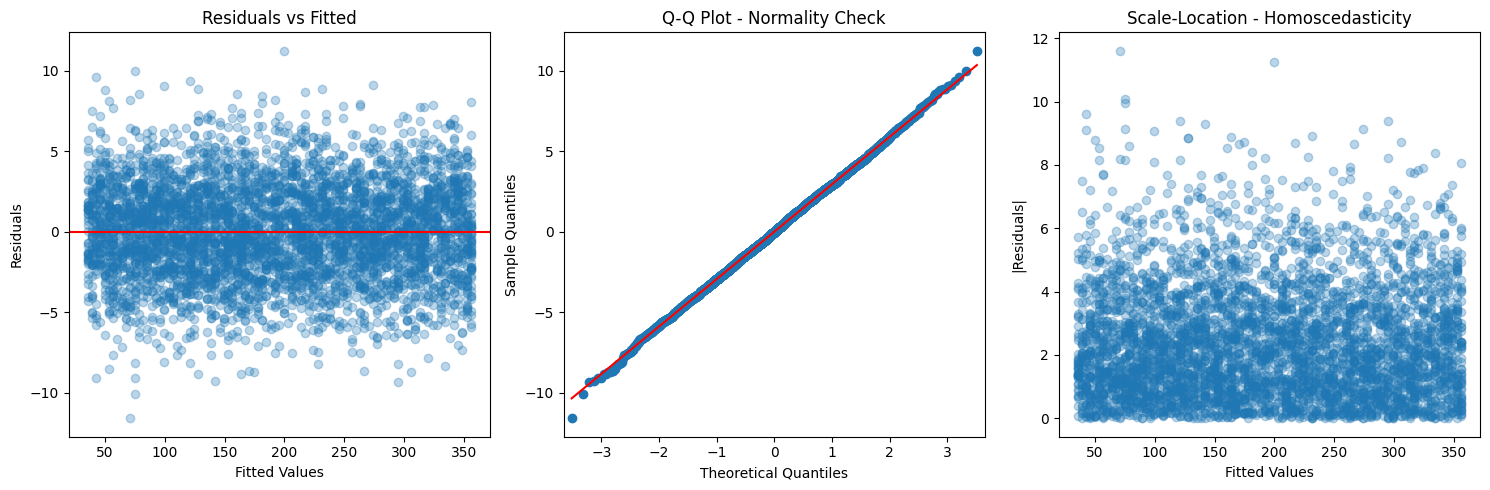

In [8]:
# Diagnostic plots
fitted = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Residuals vs Fitted (Linearity)
axes[0].scatter(fitted, residuals, alpha=0.3)
axes[0].axhline(0, color='red')
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Plot 2: Q-Q Plot (Normality)
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot - Normality Check')

# Plot 3: Scale-Location (Homoscedasticity)
axes[2].scatter(fitted, abs(residuals), alpha=0.3)
axes[2].set_title('Scale-Location - Homoscedasticity')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('|Residuals|')

plt.tight_layout()
plt.show()

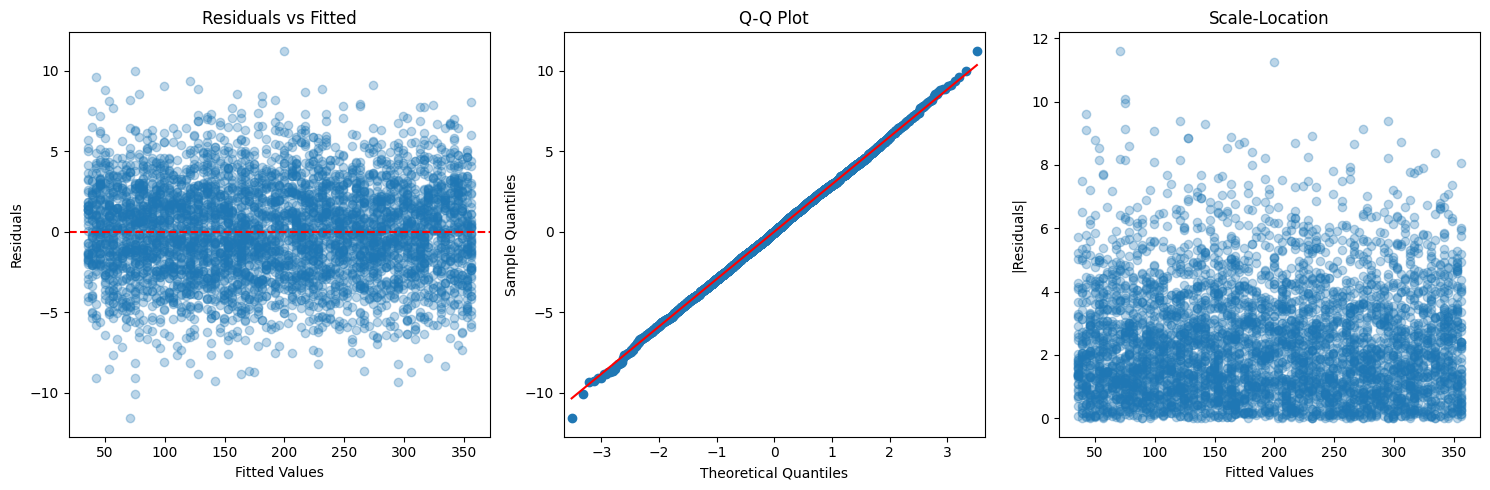

In [9]:
# Diagnostic plots
fitted = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Residuals vs Fitted (Linearity)
axes[0].scatter(fitted, residuals, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Plot 2: Q-Q Plot (Normality)
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot')

# Plot 3: Scale-Location (Homoscedasticity)
axes[2].scatter(fitted, abs(residuals), alpha=0.3)
axes[2].set_title('Scale-Location')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('|Residuals|')

plt.tight_layout()
plt.show()

In [10]:
# Model Interpretation
print("=" * 55)
print("MARKETING ROI ANALYSIS - KEY FINDINGS")
print("=" * 55)
print()
print("REGRESSION EQUATION:")
print("Sales = -0.13 + 3.56 * TV")
print()
print("R-SQUARED: 0.999")
print("TV explains 99.9% of the variation in Sales")
print()
print("TV COEFFICIENT: 3.56")
print("Every $1 increase in TV budget generates $3.56 in Sales")
print()
print("P-VALUE: 0.000")
print("TV is statistically significant at 99% confidence level")
print()
print("ASSUMPTION CHECKS:")
print("Linearity     - Residuals randomly scattered around 0")
print("Normality     - Q-Q plot points follow the line closely")
print("Homoscedasticity - Residuals evenly spread across fitted values")
print()
print("RECOMMENDATION:")
print("Allocate majority of marketing budget to TV advertising")
print("TV delivers the strongest ROI at $3.56 per $1 spent")
print("=" * 55)

MARKETING ROI ANALYSIS - KEY FINDINGS

REGRESSION EQUATION:
Sales = -0.13 + 3.56 * TV

R-SQUARED: 0.999
TV explains 99.9% of the variation in Sales

TV COEFFICIENT: 3.56
Every $1 increase in TV budget generates $3.56 in Sales

P-VALUE: 0.000
TV is statistically significant at 99% confidence level

ASSUMPTION CHECKS:
Linearity     - Residuals randomly scattered around 0
Normality     - Q-Q plot points follow the line closely
Homoscedasticity - Residuals evenly spread across fitted values

RECOMMENDATION:
Allocate majority of marketing budget to TV advertising
TV delivers the strongest ROI at $3.56 per $1 spent
